##IMPORTS

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy.signal import periodogram


In [ ]:
data = pd.read_csv("powerconsumption.csv")

data["Datetime"] = pd.to_datetime(data["PowerConsumption_Zone1"])
data = data.sort_values("Datetime").set_index("Datetime")
serie = data["PowerConsumption_Zone1"].dropna()
 
if not isinstance(serie, pd.Series):
    serie = pd.Series(serie, name="PowerConsumption_Zone1")
 
PERIOD = 144   # 10-min data → 144 obs/day
 

## OVERVIEW

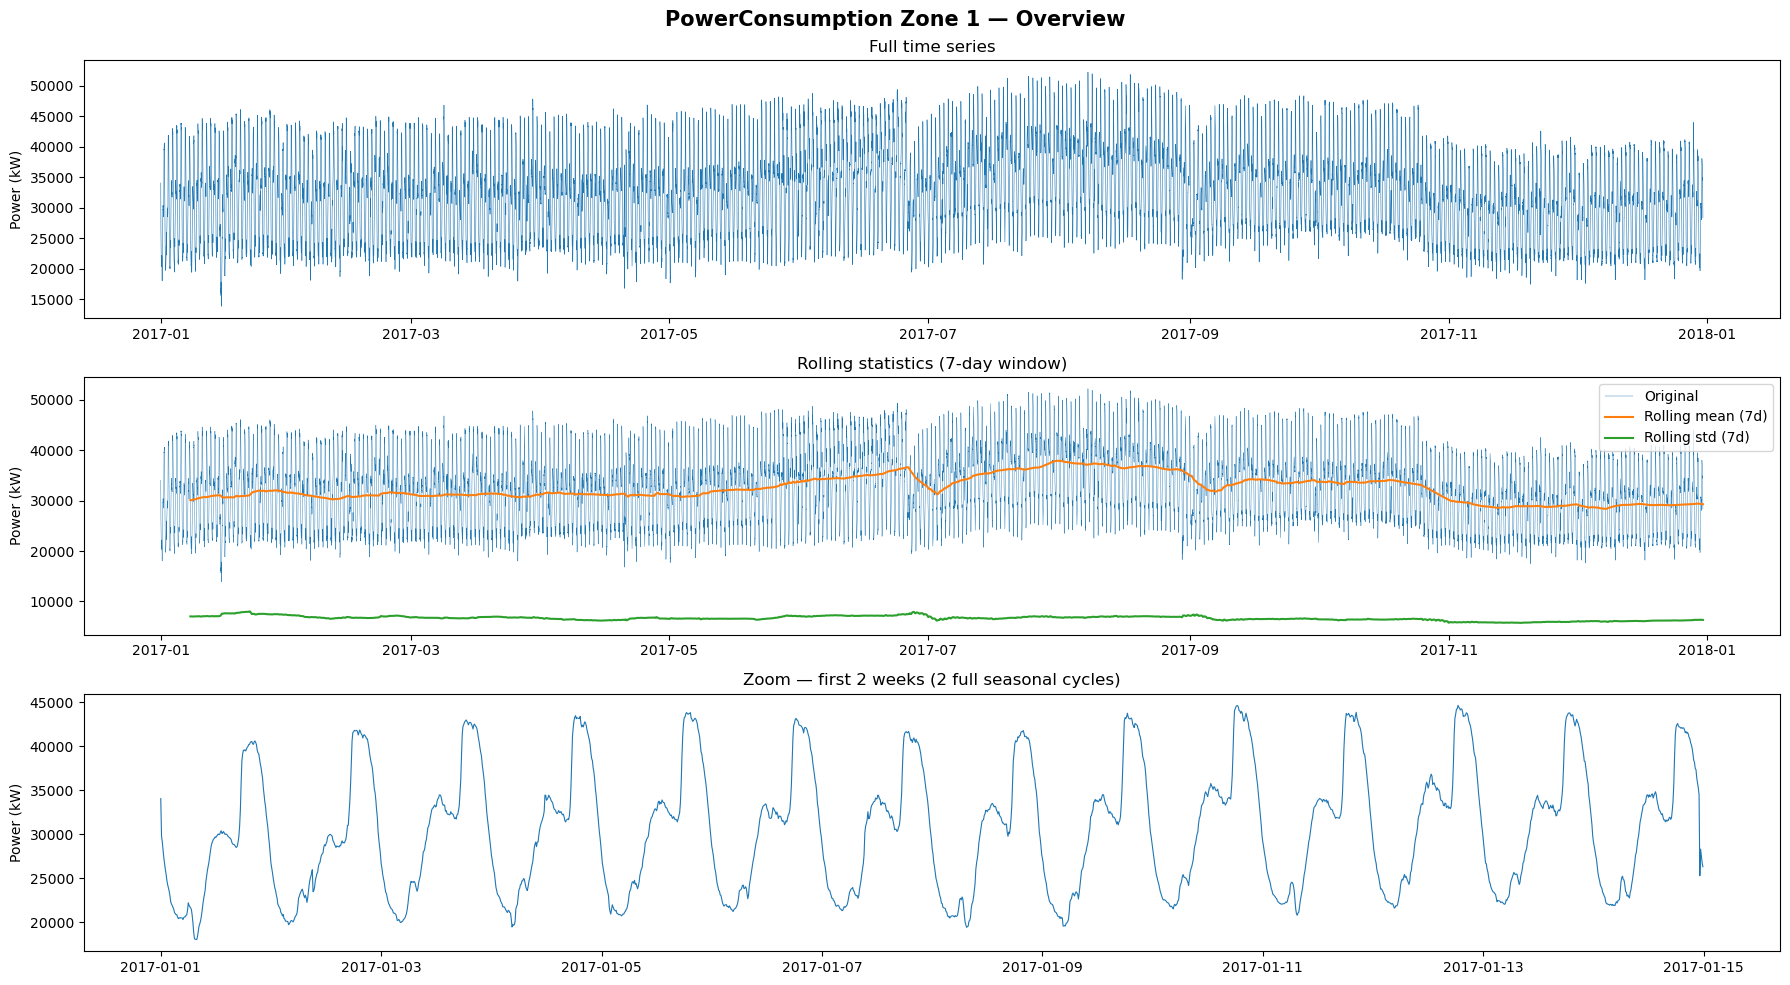

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(18, 10))
fig.suptitle("PowerConsumption Zone 1 — Overview", fontsize=15, fontweight="bold")
 
axes[0].plot(serie, linewidth=0.4, color="#1f77b4")
axes[0].set_title("Full time series")
axes[0].set_ylabel("Power (kW)")
 
roll_mean = serie.rolling(window=1008).mean()
roll_std  = serie.rolling(window=1008).std()
axes[1].plot(serie,     linewidth=0.3, label="Original")
axes[1].plot(roll_mean, linewidth=1.5, label="Rolling mean (7d)")
axes[1].plot(roll_std,  linewidth=1.5, label="Rolling std (7d)")
axes[1].set_title("Rolling statistics (7-day window)")
axes[1].set_ylabel("Power (kW)")
axes[1].legend()
 
zoom = serie.iloc[:PERIOD * 14]
axes[2].plot(zoom, linewidth=0.8)
axes[2].set_title("Zoom — first 2 weeks (2 full seasonal cycles)")
axes[2].set_ylabel("Power (kW)")
 
plt.tight_layout()
#plt.savefig("01_overview.png", dpi=150)
plt.show()

The series spans the full year 2017 (~52,000 observations at 10-min intervals).
Values range between ~15,000 and ~50,000 kW.
The 7-day rolling mean is relatively stable (~30,000 kW), with a slight rise
in summer (Jun–Jul) and a decline toward year-end, suggesting a soft annual
seasonal trend. The rolling std remains constant (~8,000 kW), indicating
homoscedasticity. The 2-week zoom confirms a very regular daily pattern
with clear diurnal peaks and nocturnal troughs.

## STL DECOMPOSITION (robust) + STRENGTH

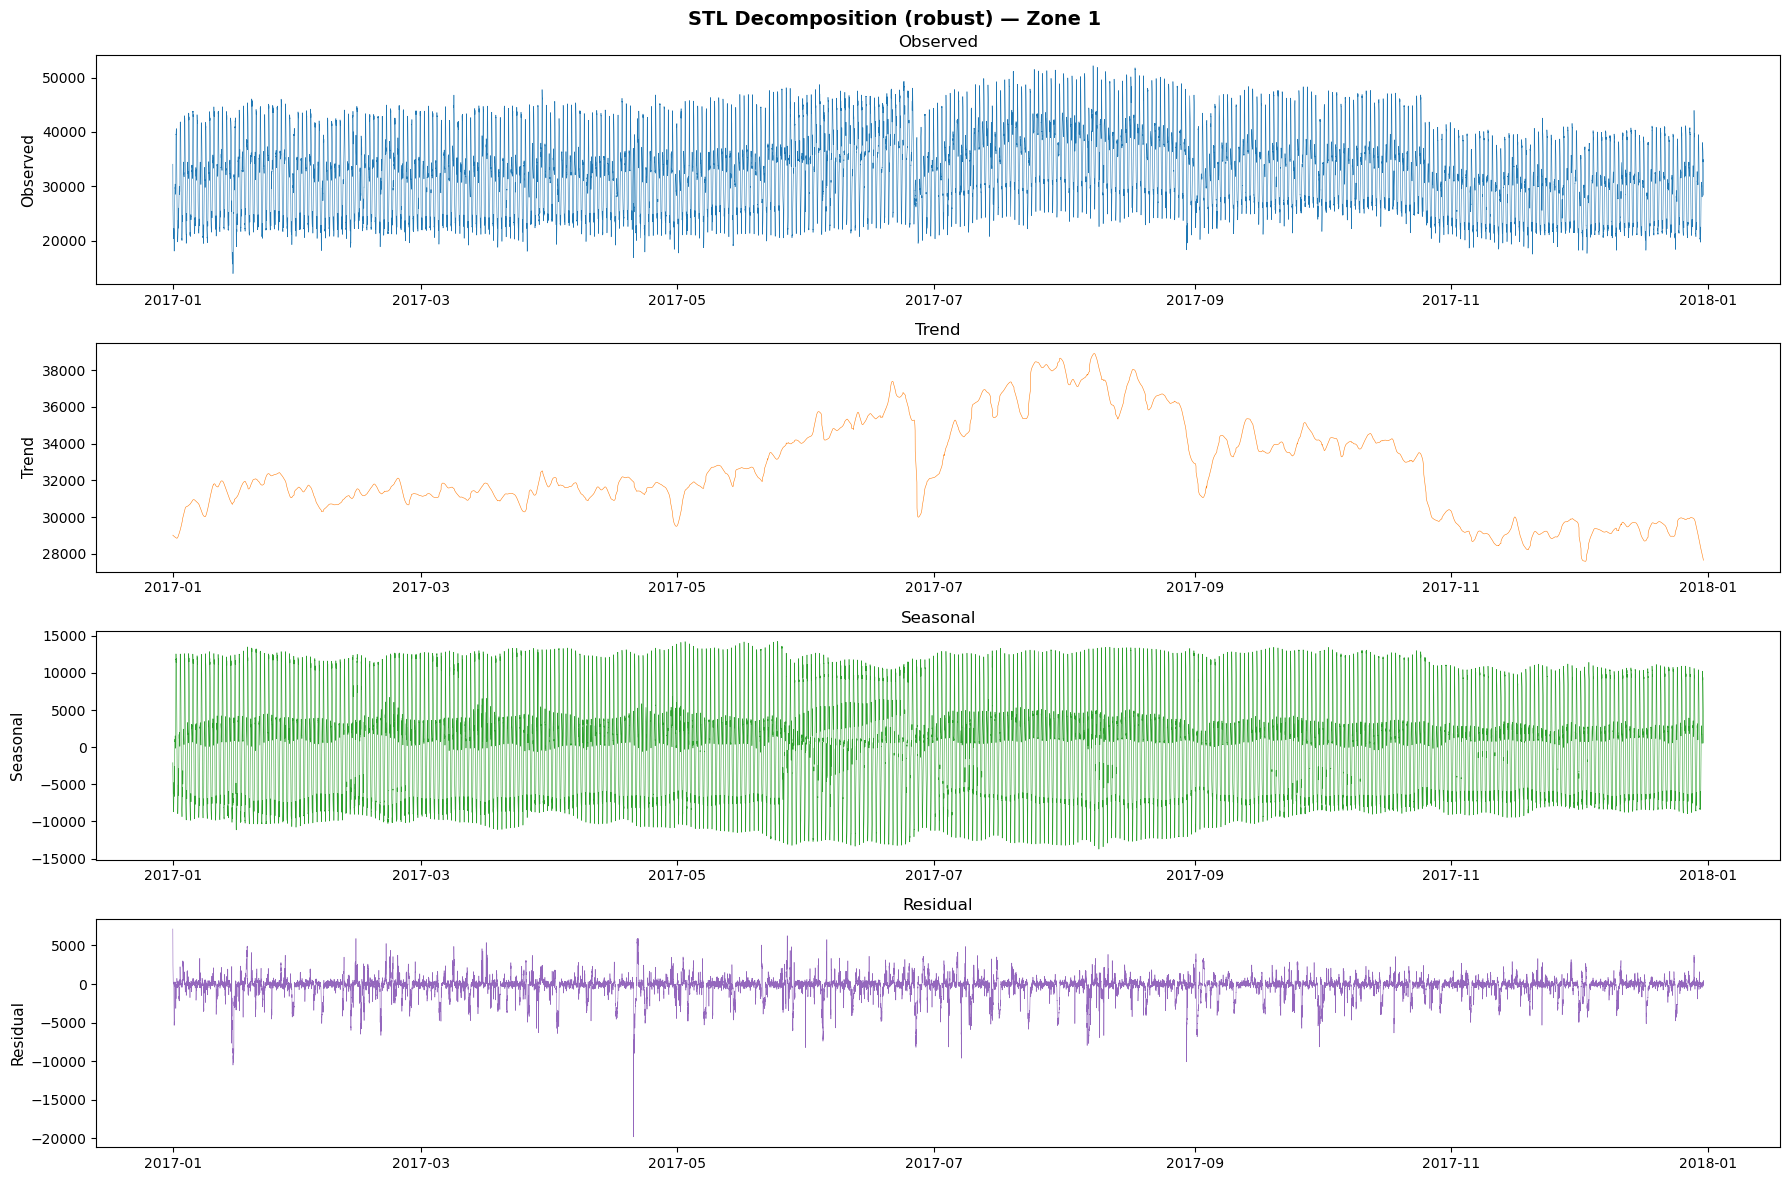


Seasonality strength : 0.9644  (>0.6 = strong)
Trend strength       : 0.8081  (>0.6 = strong)



In [17]:
stl = STL(serie, period=PERIOD, robust=True).fit()
 
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=False)
fig.suptitle("STL Decomposition (robust) — Zone 1", fontsize=14, fontweight="bold")
 
for ax, (comp, title, color) in zip(axes, [
    (stl.observed,  "Observed",  "#1f77b4"),
    (stl.trend,     "Trend",     "#ff7f0e"),
    (stl.seasonal,  "Seasonal",  "#2ca02c"),
    (stl.resid,     "Residual",  "#9467bd"),
]):
    ax.plot(comp, linewidth=0.4, color=color)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title)
 
plt.tight_layout()
#plt.savefig("02_stl_decomp.png", dpi=150)
plt.show()
 
var_resid       = np.var(stl.resid)
var_seas_resid  = np.var(stl.seasonal + stl.resid)
var_trend_resid = np.var(stl.trend   + stl.resid)
strength_seasonal = max(0, 1 - var_resid / var_seas_resid)
strength_trend    = max(0, 1 - var_resid / var_trend_resid)
 
 
print(f"""
Seasonality strength : {strength_seasonal:.4f}  (>0.6 = strong)
Trend strength       : {strength_trend:.4f}  (>0.6 = strong)
""")
 
 

La tendencia de consumo de energia a lo largo del año sube desde enero hasta agosto (quizas debido al aumento de las temperaturas) y luego baja hasta fin de año. 

El componente estacional es el patrón que se repite igual cada día. La amplitud de +-12.000 kW significa que el consumo sube y baja esa cantidad respecto a la tendencia cada ciclo diario. Es repetitivo lo que es buena señal ya que significa que es un patrin estable y predecible.

Los residuos son lo que queda después de quitar tendencia y estacionalidad, es decir, el "ruido". Que estén centrados en 0 y pequeños (la mayoria entre +-5000): significa que tendencia y estacionalidad explican casi todo. Los picos de mayo–julio son días concretos donde pasó algo fuera de lo normal (festivo, anomalía de red, dato corrupto).

0.96 de estacionalidad → el 96% de la variabilidad de la serie se explica por el ciclo diario. Es muy alto, casi toda la variación es predecible.
0.81 de tendencia → la tendencia anual también aporta bastante, aunque menos que la estacionalidad.


No podemos ignorar ni la tendencia ni la estacionalidad al construir el modelo.





## ACF / PACF

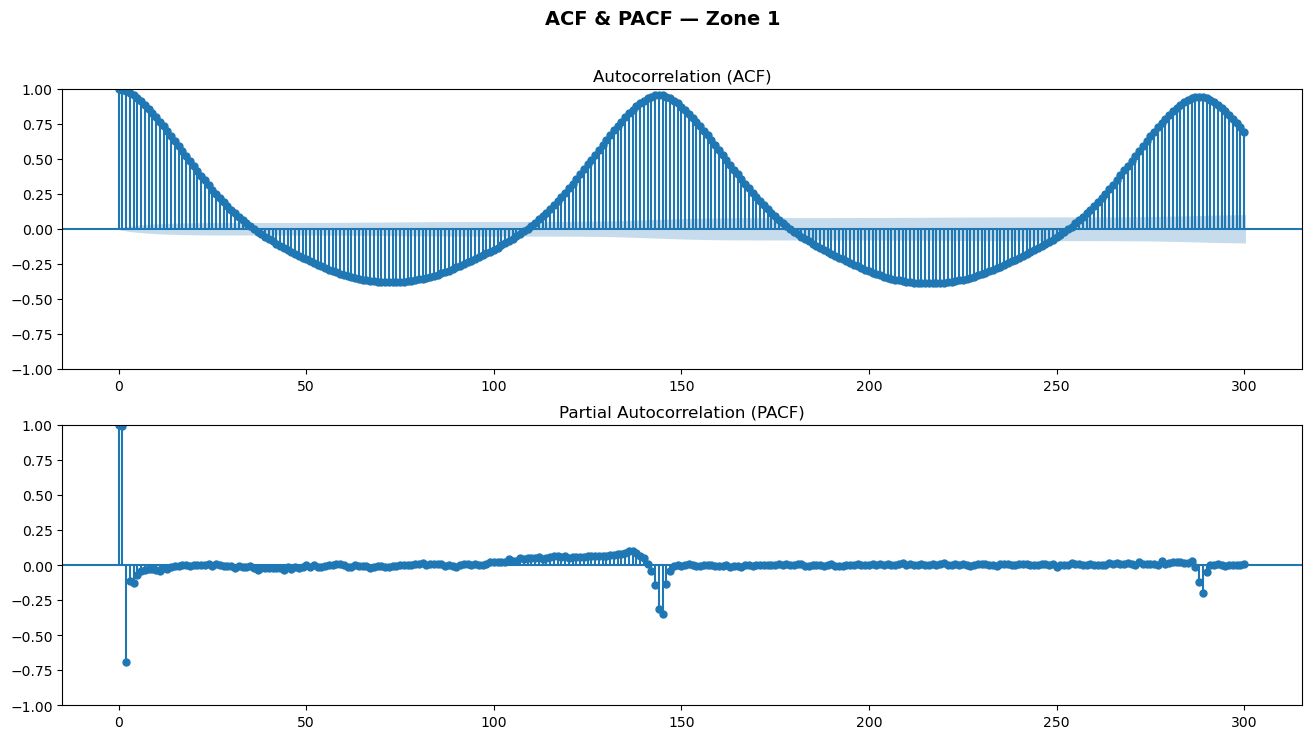

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle("ACF & PACF — Zone 1", fontsize=14, fontweight="bold")
 
plot_acf( serie, lags=300, ax=axes[0], title="Autocorrelation (ACF)")
plot_pacf(serie, lags=300, ax=axes[1], title="Partial Autocorrelation (PACF)", method="ywm")

 
# plt.savefig("03_acf_pacf.png", dpi=150)
plt.show()

El consumo actual depende principalmente del valor de hace 10 minutos  además también depende del valor de hace 20 minutos (~-0.75) sugiere que si el consumo subió mucho en el paso anterior, tiende a corregirse.

Los picos menores que aparecen alrededor del lag 144 en la PACF indican que, además de la dependencia con los valores inmediatos anteriores, hay una dependencia directa con el 
mismo momento del día anterior.

La ACF te dice que hay estacionalidad diaria fuerte.

## STATIONARITY TEST (ADF)

In [ ]:
ADF_result = adfuller(serie)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')
serie
ADF_result = adfuller(serie)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')



ADF Statistic: -32.121278534626
p-value: 0.0


La serie oscila de forma predecible alrededor de una media estable

## PERIODOGRAM 

C:\Users\gonzalo.iglesias\AppData\Local\Temp\ipykernel_8204\2358360053.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


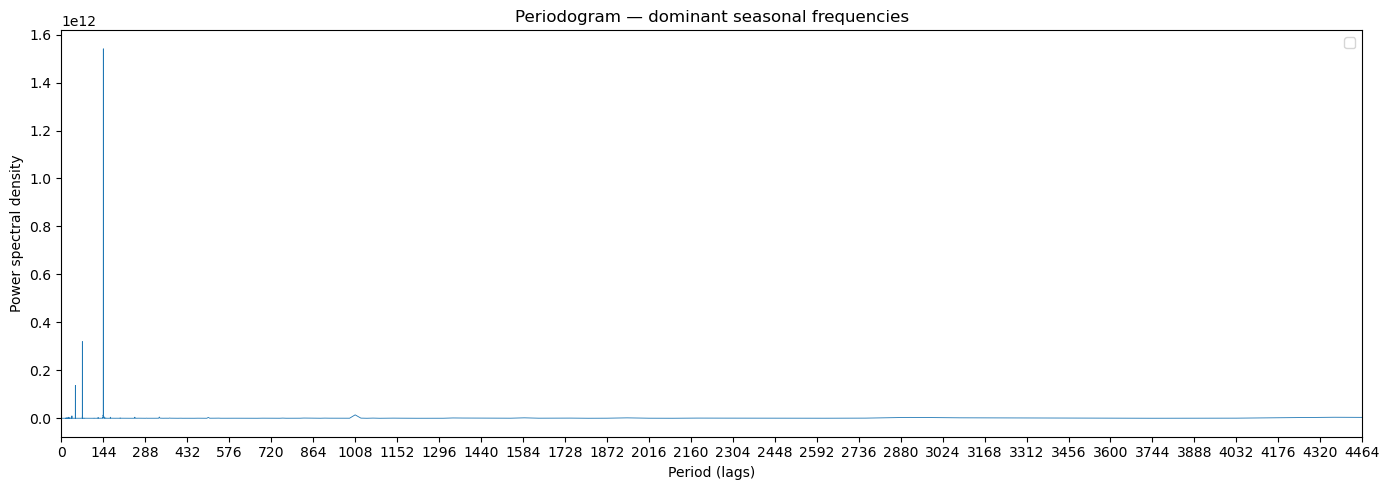

In [25]:
freqs, power = periodogram(serie.values)
periods = 1 / freqs[1:]
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(periods, power[1:], linewidth=0.6, color="#1f77b4")
#ax.axvline(PERIOD,     color="red",    linestyle="--", label=f"Daily ({PERIOD})")
#ax.axvline(PERIOD * 7, color="orange", linestyle="--", label=f"Weekly ({PERIOD*7})")
ax.set_xlim(0, PERIOD * 10)
ax.set_xlabel("Period (lags)")
ax.set_ylabel("Power spectral density")
ax.set_xticks(range(0, PERIOD * 31 + 1, PERIOD))
ax.set_title("Periodogram — dominant seasonal frequencies")
ax.legend()
plt.tight_layout()
#plt.savefig("04_periodogram.png", dpi=150)
plt.show()

El periodograma descompone la serie en frecuencias y mide cuánta "energía" o variación aporta cada una.

El pico en lag 144 tiene una potencia mucho mayor a las demas, que es un número enorme comparado con el resto. Esto significa que el ciclo de 144 pasos (= 24 horas) es con diferencia el patrón que más explica el comportamiento de la serie.

También hay un pico en lag 1008, que corresponde a 7 días (144 × 7 = 1008). Su energía esmucho menor menor que el pico diario. Existe un patrón semanal (lunes se consume diferente que domingo, por ejemplo), pero es mucho menos dominante que el diario.

De todos los ciclos posibles (horario, diario, semanal, mensual...) el diario es el que concentra casi toda la variabilidad




